In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
df =  pd.read_csv("/Users/golisairam/Downloads/netflix_titles.csv")


df.head()
df.info()
df.isnull().sum()


<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [6]:
df["date_added"]=pd.to_datetime(df["date_added"],errors="coerce")

In [10]:
df['director'] =  df['director'].fillna('UnKnown')
df['cast'] = df['cast'].fillna('Not Available')
df['country']  =  df['country'].fillna("UnKnown")
df['rating'] = df['rating'].fillna("Not Rated")
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Available,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,UnKnown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",UnKnown,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,UnKnown,Not Available,UnKnown,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,UnKnown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,UnKnown,Not Available,UnKnown,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


In [17]:
df['release_year'] =  df['release_year'].astype(int)
df['content_type']  = df['type']
df["is_movie"] = df["type"].apply(
    lambda x: 1 if x == "Movie" else 0
)
df["release_decade"] = (
    df["release_year"] // 10
) * 10

country_counts = (
    df["country"]
    .str.split(", ")
    .explode()
    .value_counts()
)

top_5_countries = country_counts.head(5)

print(top_5_countries)

country
United States     3689
India             1046
United Kingdom     804
Canada             445
France             393
Name: count, dtype: int64


In [18]:
sns.set(style = "whitegrid")


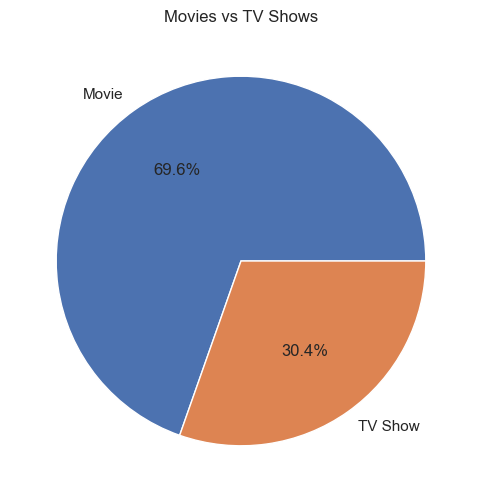

In [19]:
type_counts = df["type"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    type_counts,
    labels=type_counts.index,
    autopct="%1.1f%%"
)

plt.title("Movies vs TV Shows")

plt.show()

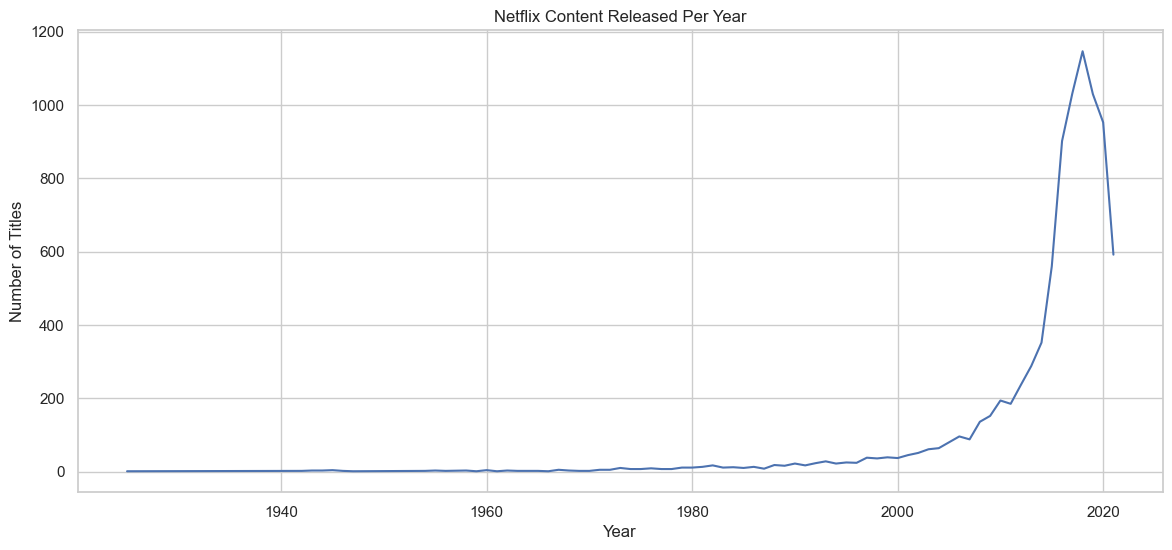

In [20]:
yearly_content = (
    df["release_year"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(14,6))

plt.plot(
    yearly_content.index,
    yearly_content.values
)

plt.title("Netflix Content Released Per Year")

plt.xlabel("Year")

plt.ylabel("Number of Titles")

plt.show()

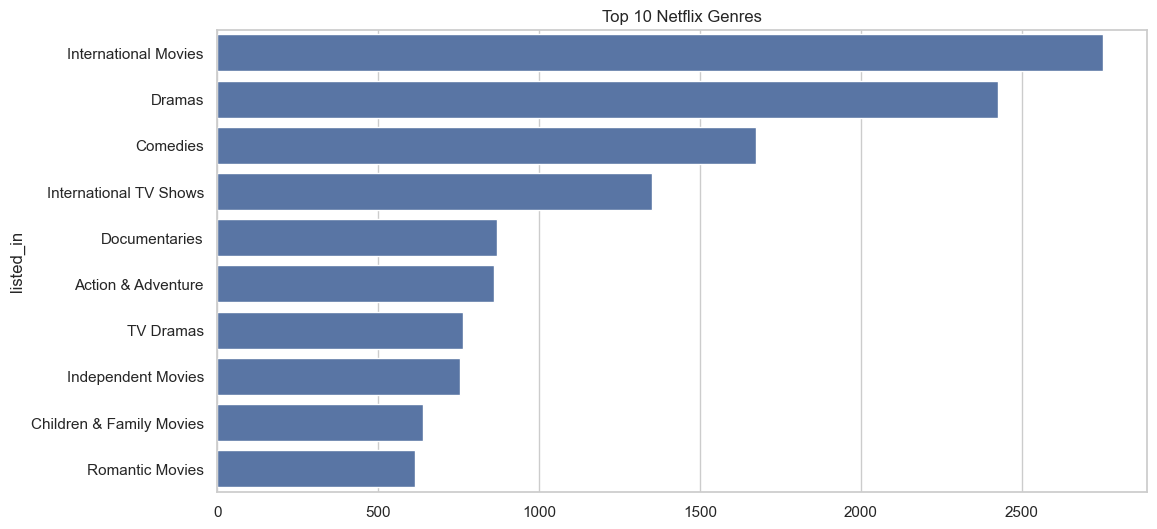

In [21]:
genres = (
    df["listed_in"]
    .str.split(", ")
    .explode()
)

top_genres = genres.value_counts().head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_genres.values,
    y=top_genres.index
)

plt.title("Top 10 Netflix Genres")

plt.show()

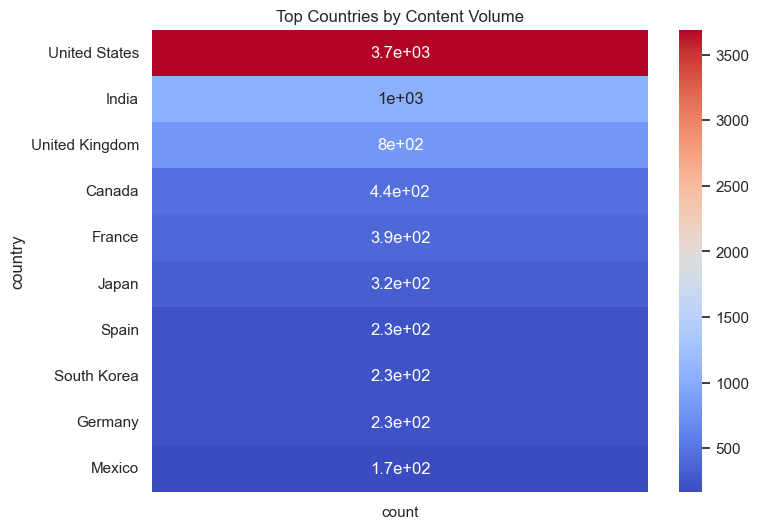

In [22]:
top_countries = country_counts.head(10).index

country_data = (
    df["country"]
    .str.split(", ")
    .explode()
)

country_df = country_data.value_counts().loc[top_countries]

heatmap_data = pd.DataFrame(country_df)

plt.figure(figsize=(8,6))

sns.heatmap(
    heatmap_data,
    annot=True,
    cmap="coolwarm"
)

plt.title("Top Countries by Content Volume")

plt.show()

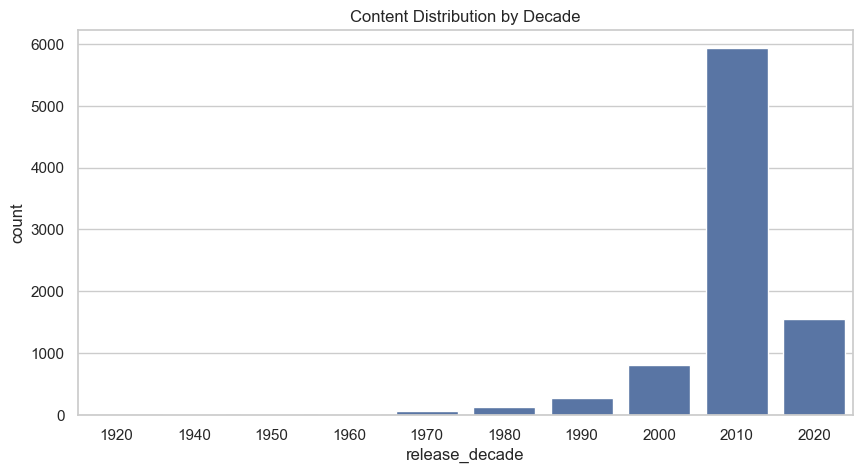

In [23]:
plt.figure(figsize=(10,5))

sns.countplot(
    x="release_decade",
    data=df
)

plt.title("Content Distribution by Decade")

plt.show()

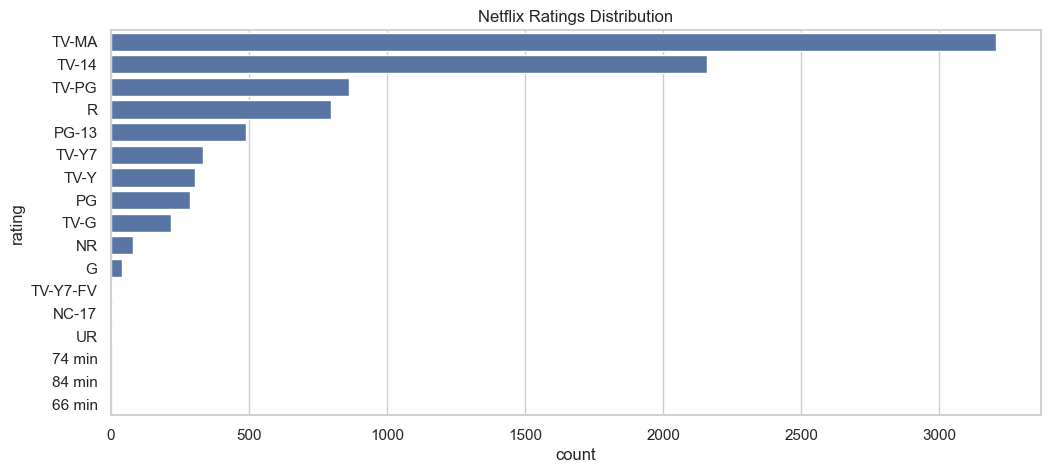

In [24]:
plt.figure(figsize=(12,5))

sns.countplot(
    y="rating",
    data=df,
    order=df["rating"].value_counts().index
)

plt.title("Netflix Ratings Distribution")

plt.show()

In [29]:
from sklearn.linear_model import LinearRegression
year_df = yearly_content.reset_index()
year_df.columns = ['year','count']
X = year_df[['year']]
y = year_df['count']
model = LinearRegression()
model.fit(X,y)

feature_years = pd.DataFrame({
    'year':[2025,2026]
})

prediction  = model.predict(feature_years)
print(prediction)

[404.13235182 411.01613454]


In [ ]:
'''TASK 4 Summary — Netflix Titles Dataset EDA & Insights  Objective

The goal of this project was to analyze Netflix content trends, genres, countries, and release patterns using exploratory data analysis.

---> What Was Done
--> Data Cleaning
Converted date_added to datetime
Filled missing values in director, cast, country
Cleaned multi-value columns
--> Feature Engineering

Created features such as:
release_decade
content_type
is_movie
Country-wise content analysis



 Visualization & Analysis

Built:
Pie charts
Line plots
Genre barplots
Country heatmaps
Trend prediction charts

-->Key Insights
Netflix contains more movies than TV shows.
Content production increased rapidly after 2015.
The United States contributes the most content.
Drama and International Movies are highly popular genres.
Most Netflix content is modern (2000s onward).
TV-MA is one of the most common ratings.

--> What Does This Mean?

Netflix focuses on:
global audience expansion
modern entertainment trends
large-scale content production
mature and international content

The analysis shows how streaming platforms use data-driven content strategies to attract and retain viewers globally.
'''